# AOC Simplification Strategy Lab

Development-only notebook for the Wine map strategy reset.

The new route is AOC-first simplification, not generated region blobs. This lab compares the existing app Wine GeoJSON with a repaired, inspectable, appellation-level simplification pipeline inspired by the useful parts of `France_Wine2.ipynb`.

Nothing here imports the production Dash app or writes to `assets/data`.

## Setup

Default region is `Bordeaux` because it exists in the old app asset and the new AOC source, and it exposes overlap/nesting issues. Edit parameters here, then run downward one section at a time.

In [2]:
from pathlib import Path
import json
import re

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

try:
    from shapely import make_valid
except ImportError:
    try:
        from shapely.validation import make_valid
    except ImportError:
        make_valid = None

from shapely.geometry import MultiPolygon
from shapely.ops import unary_union

plt.rcParams.update({
    "figure.figsize": (14, 9),
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "white",
})


def find_project_root(start):
    for candidate in [start, *start.parents]:
        old_path = candidate / "assets" / "data" / "wine_regions_cleaned.geojson"
        source_path = candidate / "Development" / "WineData" / "aoc_regions.gpkg"
        if old_path.exists() and source_path.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find both wine data sources from "
        f"{start}. Open this notebook from inside the Michelin repo, or set PROJECT_ROOT manually."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
OLD_WINE_PATH = PROJECT_ROOT / "assets" / "data" / "wine_regions_cleaned.geojson"
AOC_SOURCE_PATH = PROJECT_ROOT / "Development" / "WineData" / "aoc_regions.gpkg"
EXPORT_DIR = PROJECT_ROOT / "Development" / "WineData" / "generated" / "aoc_simplification_benchmark" / "lab_exports"

WORK_CRS = "EPSG:2154"
EXPORT_CRS = "EPSG:4326"
REQUIRED_AOC_COLUMNS = ["region", "app", "colour", "geometry"]
REGION_COLUMN_CANDIDATES = ["region", "Region", "REGION", "name", "Name", "nom", "Nom"]

REGION_NAME = "Alsace"

BUFFER_DIST_M = 500
SIMPLIFY_M = 250
OVERLAP_CLIP_ENABLED = True
EXTRACT_LARGEST_POLYGON = False
MIN_PART_AREA_M2 = 0
MAX_PARTS_PER_APP = None

PRIORITY_MISSING_REGIONS = ["Sud-Ouest", "Savoie", "Jura", "Corse"]

## Helpers

Small visible helpers for plotting, repair, counting, and metrics. The selected-region pipeline itself remains in the stage cells below.

In [3]:
def slugify(value):
    slug = re.sub(r"[^A-Za-z0-9]+", "_", str(value).strip()).strip("_").lower()
    return slug or "region"


def detect_region_column(columns):
    for candidate in REGION_COLUMN_CANDIDATES:
        if candidate in columns:
            return candidate
    return None


def collect_polygon_parts(geom):
    if geom is None or geom.is_empty:
        return []
    if geom.geom_type == "Polygon":
        return [geom]
    if geom.geom_type == "MultiPolygon":
        return [part for part in geom.geoms if not part.is_empty]
    if geom.geom_type == "GeometryCollection":
        parts = []
        for child in geom.geoms:
            parts.extend(collect_polygon_parts(child))
        return parts
    return []


def repair_one(geom):
    if geom is None or geom.is_empty:
        return None
    repaired = geom
    if make_valid is not None:
        try:
            repaired = make_valid(geom, method="structure", keep_collapsed=False)
        except TypeError:
            repaired = make_valid(geom)
        except Exception:
            repaired = geom
    if repaired is not None and not repaired.is_empty and not repaired.is_valid:
        try:
            repaired = repaired.buffer(0)
        except Exception:
            pass
    parts = collect_polygon_parts(repaired)
    if not parts:
        return None
    return parts[0] if len(parts) == 1 else MultiPolygon(parts)


def repair_frame(gdf):
    repaired = gdf.copy()
    repaired.geometry = repaired.geometry.apply(repair_one)
    repaired = repaired[repaired.geometry.notna()].copy()
    repaired = repaired[~repaired.geometry.is_empty].copy()
    return repaired


def count_coordinates(geom):
    if geom is None or geom.is_empty:
        return 0
    geom_type = geom.geom_type
    if geom_type == "Point":
        return 1
    if geom_type == "MultiPoint":
        return sum(count_coordinates(part) for part in geom.geoms)
    if geom_type in {"LineString", "LinearRing"}:
        return len(geom.coords)
    if geom_type == "MultiLineString":
        return sum(count_coordinates(part) for part in geom.geoms)
    if geom_type == "Polygon":
        exterior = len(geom.exterior.coords) if geom.exterior else 0
        interiors = sum(len(ring.coords) for ring in geom.interiors)
        return exterior + interiors
    if geom_type == "MultiPolygon":
        return sum(count_coordinates(part) for part in geom.geoms)
    if geom_type == "GeometryCollection":
        return sum(count_coordinates(part) for part in geom.geoms)
    return 0


def count_polygon_parts(geom):
    if geom is None or geom.is_empty:
        return 0
    if geom.geom_type == "Polygon":
        return 1
    if geom.geom_type == "MultiPolygon":
        return len(geom.geoms)
    if geom.geom_type == "GeometryCollection":
        return sum(count_polygon_parts(part) for part in geom.geoms)
    return 0


def plot_frame(gdf, title, *, ax=None, color=None, edgecolor="black", linewidth=0.25, alpha=1.0):
    if gdf is None or gdf.empty:
        print(f"No geometry to plot for: {title}")
        return ax
    plot_gdf = gdf.to_crs(EXPORT_CRS) if gdf.crs is not None else gdf
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    kwargs = {"ax": ax, "edgecolor": edgecolor, "linewidth": linewidth, "alpha": alpha}
    if color is not None:
        kwargs["color"] = color
    elif "colour" in plot_gdf.columns:
        kwargs["color"] = plot_gdf["colour"].fillna("#8a6f96")
    else:
        kwargs["color"] = "#8a6f96"
    plot_gdf.plot(**kwargs)
    ax.set_title(title)
    ax.set_axis_off()
    ax.set_aspect("equal")
    return ax


def metrics_for_frame(label, gdf, *, app_column="app"):
    if gdf is None or gdf.empty:
        return {
            "label": label, "feature_count": 0, "app_count": 0, "coordinate_count": 0,
            "geometry_part_count": 0, "invalid_geometry_count": 0, "empty_geometry_count": 0,
            "approx_geojson_size_mb": 0, "area_m2_epsg_2154": 0,
        }
    metric_gdf = gdf.to_crs(WORK_CRS) if gdf.crs is not None else gdf
    approx_size_mb = len(gdf.to_crs(EXPORT_CRS).to_json().encode("utf-8")) / (1024 * 1024) if gdf.crs is not None else None
    return {
        "label": label,
        "feature_count": int(len(gdf)),
        "app_count": int(gdf[app_column].nunique()) if app_column in gdf.columns else None,
        "coordinate_count": int(gdf.geometry.apply(count_coordinates).sum()),
        "geometry_part_count": int(gdf.geometry.apply(count_polygon_parts).sum()),
        "invalid_geometry_count": int((~gdf.geometry.is_valid).sum()),
        "empty_geometry_count": int(gdf.geometry.is_empty.sum()),
        "approx_geojson_size_mb": round(approx_size_mb, 4) if approx_size_mb is not None else None,
        "area_m2_epsg_2154": float(metric_gdf.geometry.area.sum()),
    }


def per_region_metrics(gdf, region_column):
    rows = []
    metric_gdf = gdf.to_crs(WORK_CRS) if gdf.crs is not None else gdf
    for region, group in gdf.groupby(region_column, sort=True):
        metric_group = metric_gdf.loc[group.index]
        rows.append({
            "region": region,
            "feature_count": int(len(group)),
            "coordinate_count": int(group.geometry.apply(count_coordinates).sum()),
            "geometry_part_count": int(group.geometry.apply(count_polygon_parts).sum()),
            "invalid_geometry_count": int((~group.geometry.is_valid).sum()),
            "empty_geometry_count": int(group.geometry.is_empty.sum()),
            "area_m2_epsg_2154": float(metric_group.geometry.area.sum()),
        })
    return pd.DataFrame(rows)

## A. Old App Data Benchmark

Load the current deployed Wine geometry. This is the benchmark for acceptable app-scale size/detail, not the target schema.

In [4]:
old_wine = gpd.read_file(OLD_WINE_PATH, engine="pyogrio")
old_region_column = detect_region_column(list(old_wine.columns))

old_summary = pd.Series({
    "path": str(OLD_WINE_PATH),
    "file_size_mb": round(OLD_WINE_PATH.stat().st_size / (1024 * 1024), 3),
    "crs": str(old_wine.crs),
    "columns": list(old_wine.columns),
    "region_column_detected": old_region_column,
    "feature_count": len(old_wine),
    "region_count": old_wine[old_region_column].nunique() if old_region_column else None,
    "region_names": sorted(old_wine[old_region_column].dropna().astype(str).unique()) if old_region_column else None,
    "geometry_type_counts": dict(old_wine.geometry.geom_type.value_counts()),
    "invalid_geometry_count": int((~old_wine.geometry.is_valid).sum()),
    "empty_geometry_count": int(old_wine.geometry.is_empty.sum()),
    "coordinate_count": int(old_wine.geometry.apply(count_coordinates).sum()),
    "geometry_part_count": int(old_wine.geometry.apply(count_polygon_parts).sum()),
}).to_frame("value")

display(old_summary)
if old_region_column is None:
    print("No known region column detected. Do not guess silently; inspect columns above.")

,value
path,/Users/Ian/Documents/Study/Stage3/Programming/...
file_size_mb,0.449
crs,EPSG:4326
columns,"[region, colour, geometry]"
region_column_detected,region
feature_count,136
region_count,9
region_names,"[Alsace, Bordeaux, Bourgogne, Champagne, Dordo..."
geometry_type_counts,{'Polygon': 136}
invalid_geometry_count,8


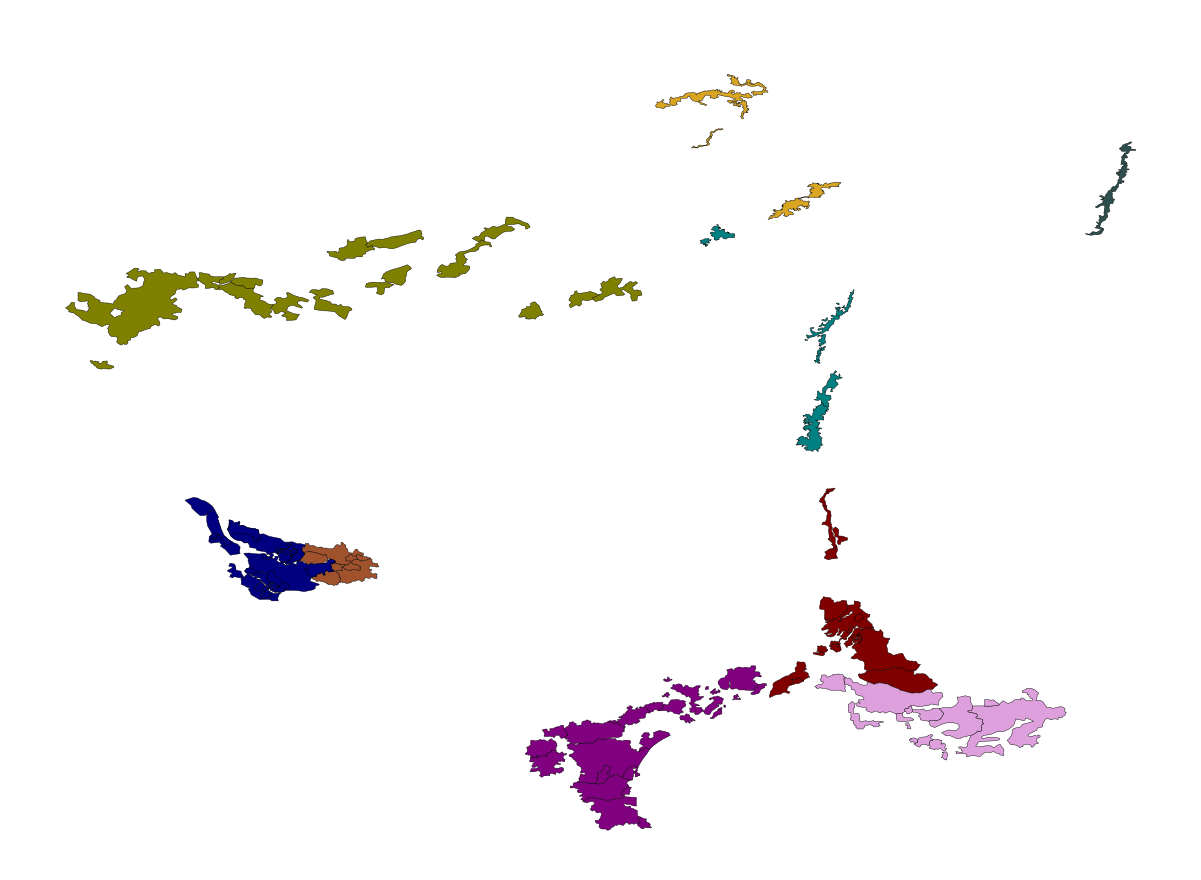

,region,feature_count,coordinate_count,geometry_part_count,invalid_geometry_count,empty_geometry_count,area_m2_epsg_2154
0,Alsace,1,331,1,0,0,3.733086e+08
1,Bordeaux,34,1551,34,0,0,4.451156e+09
2,Bourgogne,9,1881,9,4,0,8.503448e+08
3,Champagne,5,1451,5,1,0,9.449793e+08
4,Dordogne,7,592,7,1,0,1.363714e+09
5,Languedoc-Roussillon,28,1776,28,1,0,6.970845e+09
6,Loire,17,955,17,0,0,7.110242e+09
7,Provence,14,838,14,1,0,5.495256e+09
8,Rhône,21,1130,21,0,0,3.932778e+09


In [5]:
plot_frame(old_wine, "Old app Wine geometry benchmark")
plt.show()

if old_region_column:
    old_region_metrics = per_region_metrics(old_wine, old_region_column)
    display(old_region_metrics)

## B. New AOC Source Benchmark

Load the new source and inspect all regions plus the selected raw region. This source is intentionally much heavier than the deployed app asset.

In [6]:
aoc_source = gpd.read_file(AOC_SOURCE_PATH, engine="pyogrio")
missing = [column for column in REQUIRED_AOC_COLUMNS if column not in aoc_source.columns]
if missing:
    raise ValueError(f"Missing required AOC columns: {missing}")
if aoc_source.crs is None or aoc_source.crs.to_epsg() != 4326:
    raise ValueError(f"Expected AOC source CRS EPSG:4326, found {aoc_source.crs}")

aoc_source = aoc_source[REQUIRED_AOC_COLUMNS].copy()
aoc_summary = pd.Series({
    "path": str(AOC_SOURCE_PATH),
    "file_size_mb": round(AOC_SOURCE_PATH.stat().st_size / (1024 * 1024), 3),
    "crs": str(aoc_source.crs),
    "columns": list(aoc_source.columns),
    "feature_count": len(aoc_source),
    "region_count": aoc_source["region"].nunique(),
    "region_names": sorted(aoc_source["region"].dropna().astype(str).unique()),
    "aoc_app_count": aoc_source["app"].nunique(),
    "geometry_type_counts": dict(aoc_source.geometry.geom_type.value_counts()),
    "invalid_geometry_count": int((~aoc_source.geometry.is_valid).sum()),
    "empty_geometry_count": int(aoc_source.geometry.is_empty.sum()),
}).to_frame("value")

display(aoc_summary)

,value
path,/Users/Ian/Documents/Study/Stage3/Programming/...
file_size_mb,396.629
crs,EPSG:4326
columns,"[region, app, colour, geometry]"
feature_count,354
region_count,12
region_names,"[Alsace, Bordeaux, Bourgogne, Corse, Dordogne,..."
aoc_app_count,354
geometry_type_counts,{'MultiPolygon': 354}
invalid_geometry_count,74


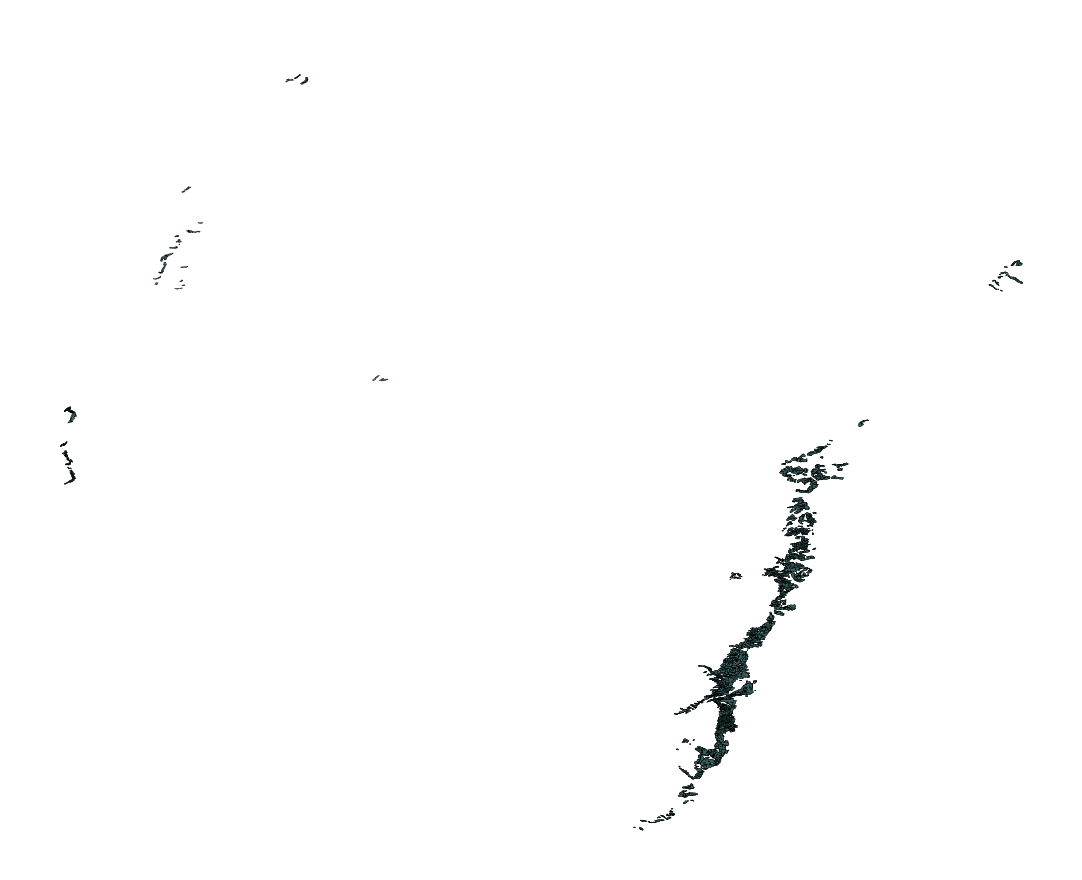

,region,feature_count,coordinate_count,geometry_part_count,invalid_geometry_count,empty_geometry_count,area_m2_epsg_2154
0,Alsace,55,265863,2626,3,0,4.322898e+08
1,Bordeaux,39,2042288,11548,12,0,1.006137e+10
2,Bourgogne,102,4421392,60401,7,0,4.779168e+09
3,Corse,4,1219799,8487,1,0,1.091303e+09
4,Dordogne,9,320413,2514,2,0,1.149448e+09
5,Jura,3,272281,4412,3,0,3.384261e+08
6,Languedoc-Roussillon,32,8459949,91615,9,0,9.789616e+09
7,Loire,53,2944498,66480,24,0,4.432516e+09
8,Provence,6,1027674,11742,3,0,1.287540e+09
9,Rhône,30,3438947,32024,5,0,3.656409e+09


,region,app,feature_count,coordinate_count,geometry_part_count
0,Alsace,Altenberg de Bergbieten,1,150,1
1,Alsace,Altenberg de Bergheim,1,253,2
2,Alsace,Altenberg de Wolxheim,1,151,1
3,Alsace,Brand,1,940,11
4,Alsace,Bruderthal,1,99,1
5,Alsace,Crémant d’Alsace,1,115943,1067
6,Alsace,Côtes de Toul,1,10200,276
7,Alsace,Eichberg,1,596,11
8,Alsace,Engelberg,1,110,2
9,Alsace,Florimont,1,215,3


In [7]:
raw_region = aoc_source.loc[aoc_source["region"].astype(str) == REGION_NAME].copy()
if raw_region.empty:
    available = sorted(aoc_source["region"].dropna().astype(str).unique())
    raise ValueError(f"No AOC rows found for REGION_NAME={REGION_NAME!r}. Available: {available}")

plot_frame(raw_region, f"Raw new AOC source: {REGION_NAME}", linewidth=0.2)
plt.show()

aoc_region_metrics = per_region_metrics(aoc_source, "region")
aoc_app_metrics = (
    aoc_source.assign(coordinate_count=aoc_source.geometry.apply(count_coordinates), part_count=aoc_source.geometry.apply(count_polygon_parts))
    .groupby(["region", "app"], sort=True)
    .agg(feature_count=("geometry", "size"), coordinate_count=("coordinate_count", "sum"), geometry_part_count=("part_count", "sum"))
    .reset_index()
)

display(aoc_region_metrics)
display(aoc_app_metrics.loc[aoc_app_metrics["region"] == REGION_NAME].head(40))

## C. Shared-Region Comparison

Compare old app geometry, raw new AOC geometry, and later the processed AOC-first candidate for `REGION_NAME`.

,regions
shared_regions,"[Alsace, Bordeaux, Bourgogne, Dordogne, Langue..."
new_only_regions,"[Corse, Jura, Savoie, Sud-Ouest]"
old_only_regions,[Champagne]


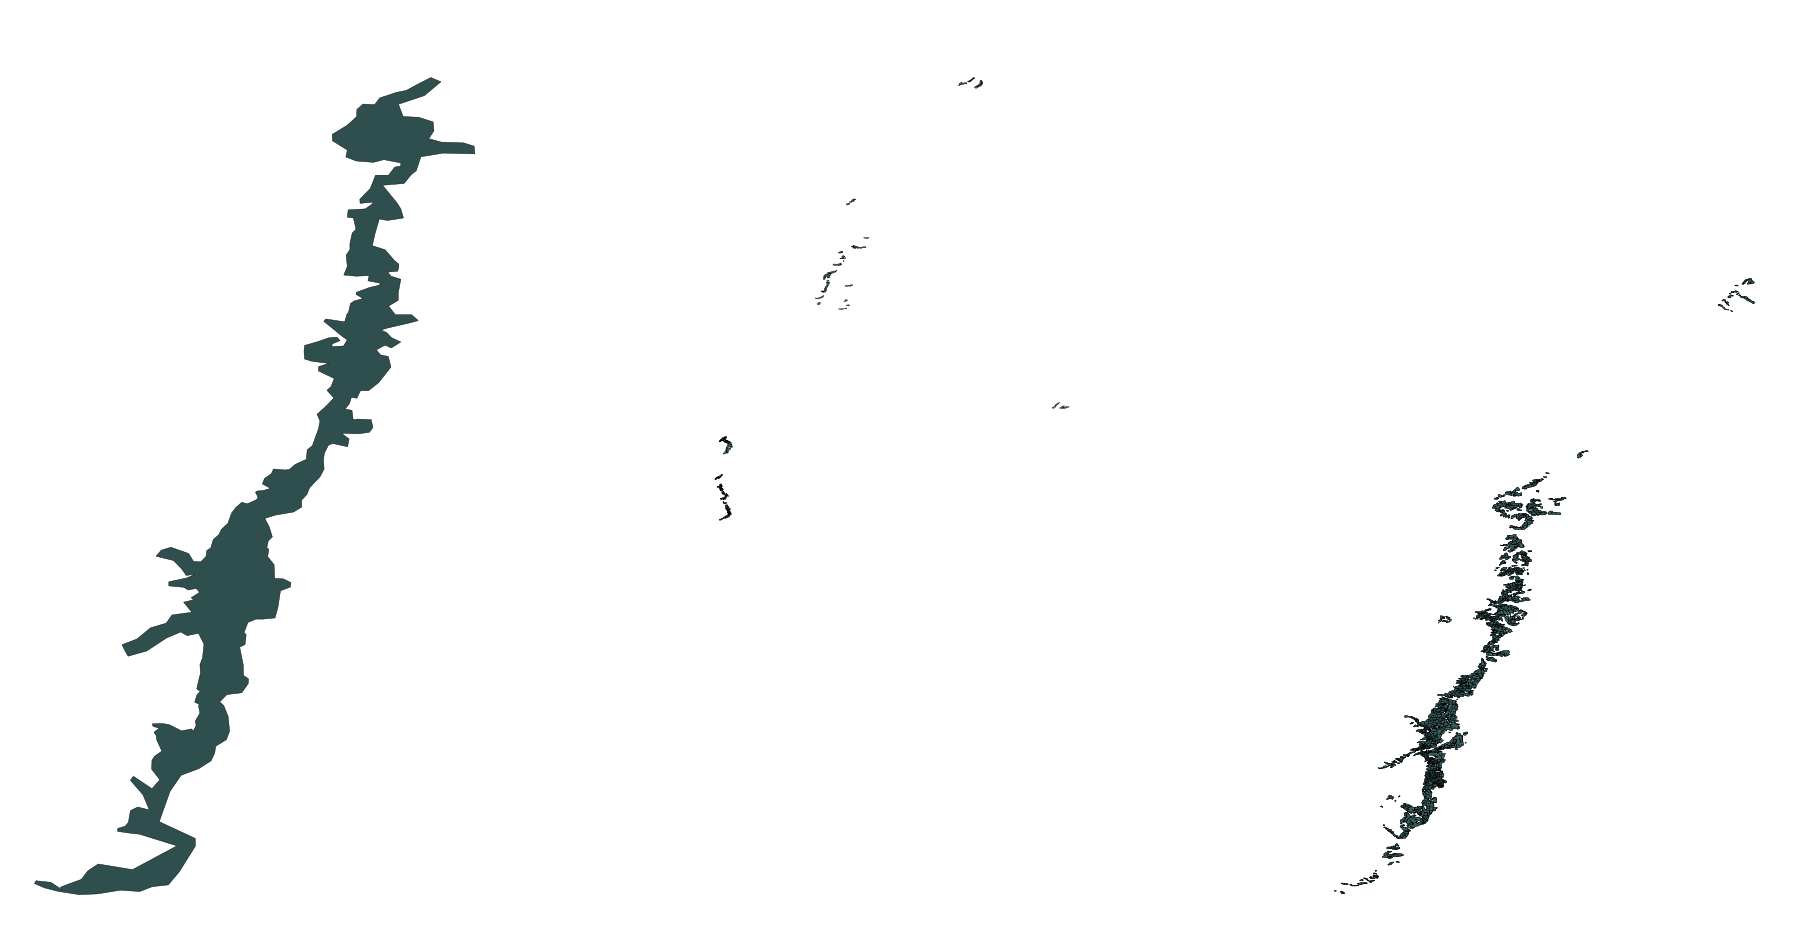

In [8]:
old_regions = set(old_wine[old_region_column].dropna().astype(str)) if old_region_column else set()
new_regions = set(aoc_source["region"].dropna().astype(str))
region_sets = pd.Series({
    "shared_regions": sorted(old_regions & new_regions),
    "new_only_regions": sorted(new_regions - old_regions),
    "old_only_regions": sorted(old_regions - new_regions),
}).to_frame("regions")
display(region_sets)

old_region = old_wine.loc[old_wine[old_region_column].astype(str) == REGION_NAME].copy() if old_region_column else gpd.GeoDataFrame(geometry=[], crs=old_wine.crs)
new_region = aoc_source.loc[aoc_source["region"].astype(str) == REGION_NAME].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=120)
fig.patch.set_facecolor("white")
plot_frame(old_region, f"Old app geometry: {REGION_NAME}", ax=axes[0])
plot_frame(new_region, f"Raw new AOCs: {REGION_NAME}", ax=axes[1], linewidth=0.2)
fig.tight_layout()
plt.show()

## D. Repaired France_Wine2-Style AOC-First Pipeline

The cells below are intentionally explicit. They avoid hidden state, stale spatial indexes, undefined drop lists, mistaken degree/metre comments, Bordeaux-only assumptions, unconditional largest-polygon extraction, and destructive pruning by default.

{'label': 'raw selected AOCs',
 'feature_count': 55,
 'app_count': 55,
 'coordinate_count': 265863,
 'geometry_part_count': 2626,
 'invalid_geometry_count': 3,
 'empty_geometry_count': 0,
 'approx_geojson_size_mb': 10.2224,
 'area_m2_epsg_2154': 432289800.41010875}

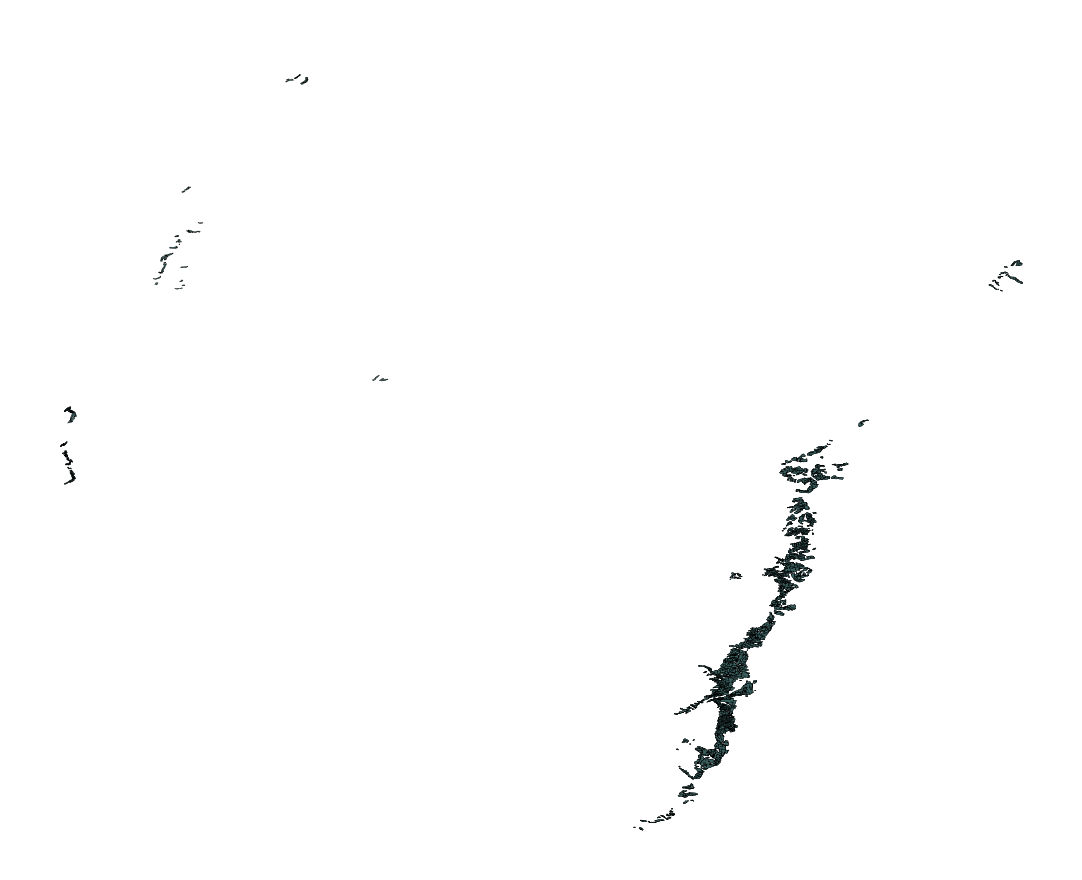

In [9]:
selected = aoc_source.loc[aoc_source["region"].astype(str) == REGION_NAME, REQUIRED_AOC_COLUMNS].copy()
selected = selected.reset_index(drop=True)
selected["source_index"] = selected.index.astype(int)
selected_metric = selected.to_crs(WORK_CRS)

display(metrics_for_frame("raw selected AOCs", selected_metric))
plot_frame(selected_metric, f"D1. Selected raw AOCs: {REGION_NAME}", linewidth=0.2)
plt.show()

{'label': 'repaired AOCs',
 'feature_count': 55,
 'app_count': 55,
 'coordinate_count': 265881,
 'geometry_part_count': 2627,
 'invalid_geometry_count': 0,
 'empty_geometry_count': 0,
 'approx_geojson_size_mb': 10.223,
 'area_m2_epsg_2154': 432289800.4101088}

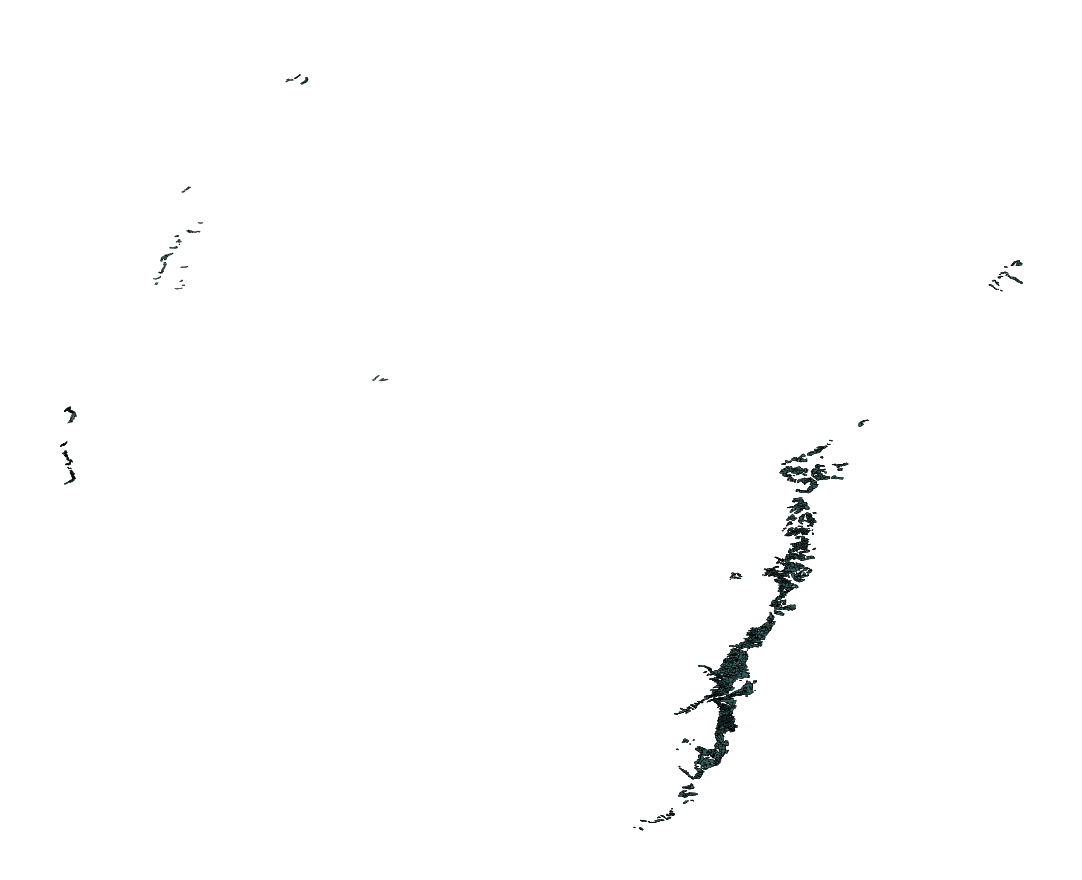

In [10]:
repaired_aocs = repair_frame(selected_metric)

display(metrics_for_frame("repaired AOCs", repaired_aocs))
plot_frame(repaired_aocs, f"D2. Repaired AOCs: {REGION_NAME}", linewidth=0.2)
plt.show()

{'label': 'overlap-clipped AOCs',
 'feature_count': 52,
 'app_count': 52,
 'coordinate_count': 141297,
 'geometry_part_count': 2452,
 'invalid_geometry_count': 0,
 'empty_geometry_count': 0,
 'approx_geojson_size_mb': 5.4409,
 'area_m2_epsg_2154': 213952653.78326365}

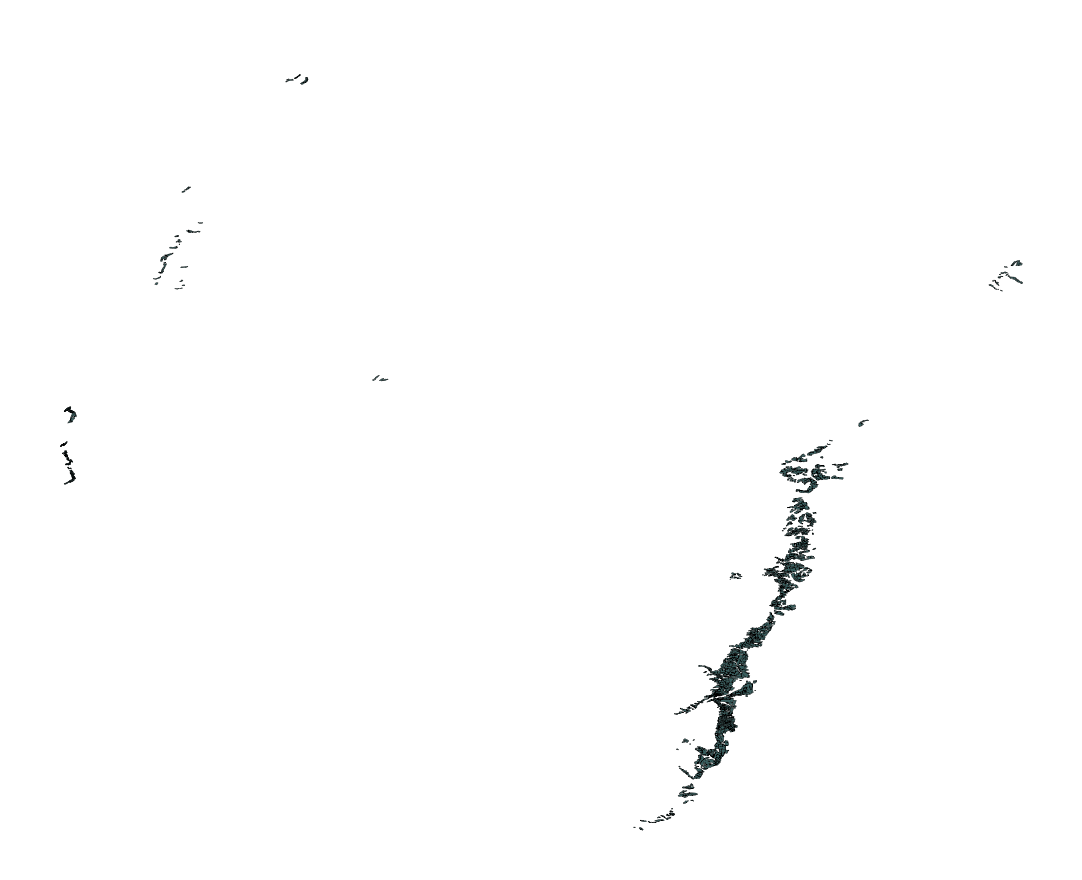

In [11]:
# Optional overlap clipping: largest polygons keep priority; smaller overlapping polygons are clipped.
# This is visually inspectable and can be disabled with OVERLAP_CLIP_ENABLED = False.
if OVERLAP_CLIP_ENABLED:
    clipped_rows = []
    kept_geometries = []
    ordered = repaired_aocs.assign(_area=repaired_aocs.geometry.area).sort_values("_area", ascending=False)
    for _, row in ordered.iterrows():
        geom = row.geometry
        if kept_geometries:
            geom = geom.difference(unary_union(kept_geometries))
        geom = repair_one(geom)
        if geom is None or geom.is_empty:
            continue
        new_row = row.drop(labels=["_area"]).copy()
        new_row["geometry"] = geom
        clipped_rows.append(new_row)
        kept_geometries.append(geom)
    overlap_clipped = gpd.GeoDataFrame(clipped_rows, geometry="geometry", crs=repaired_aocs.crs)
else:
    overlap_clipped = repaired_aocs.copy()

display(metrics_for_frame("overlap-clipped AOCs" if OVERLAP_CLIP_ENABLED else "overlap clipping disabled", overlap_clipped))
plot_frame(overlap_clipped, f"D3. Overlap-clipped AOCs: {REGION_NAME}" if OVERLAP_CLIP_ENABLED else f"D3. Overlap clipping disabled: {REGION_NAME}", linewidth=0.2)
plt.show()

{'label': 'dissolved by app',
 'feature_count': 52,
 'app_count': 52,
 'coordinate_count': 141297,
 'geometry_part_count': 2452,
 'invalid_geometry_count': 0,
 'empty_geometry_count': 0,
 'approx_geojson_size_mb': 5.44,
 'area_m2_epsg_2154': 213952653.78326365}

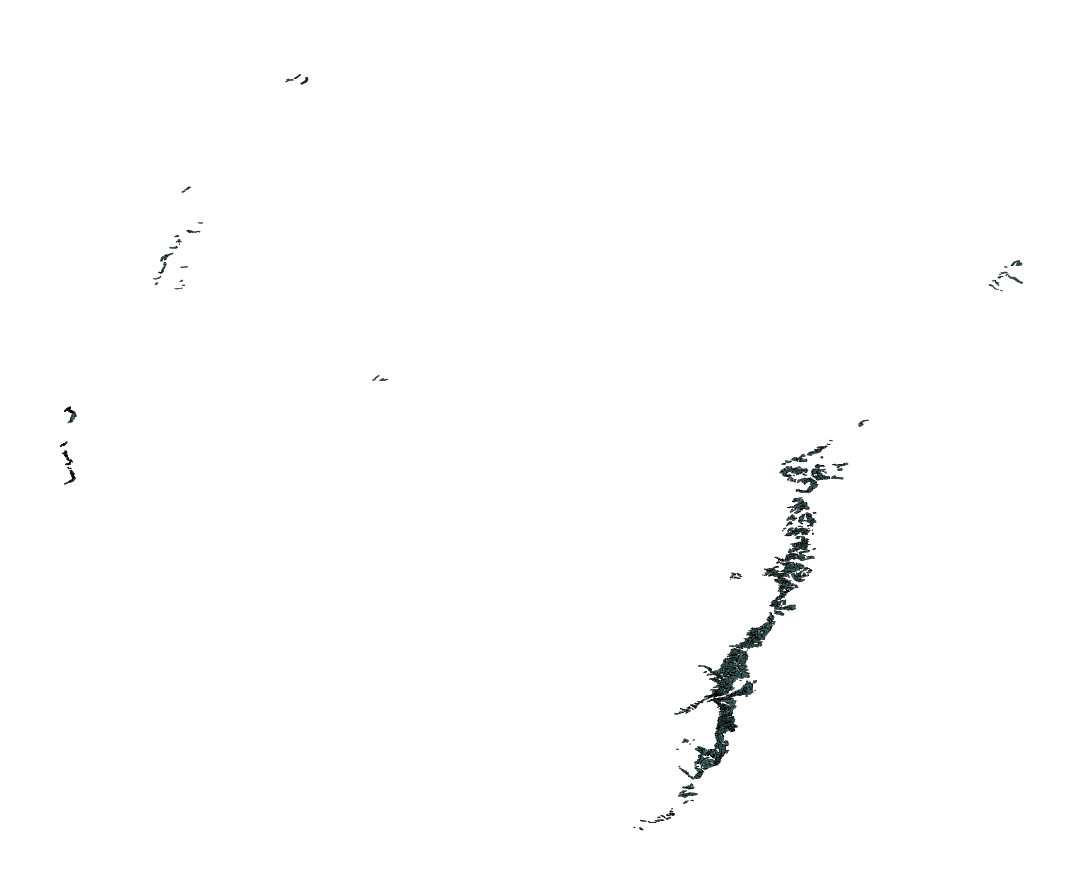

In [12]:
dissolved_by_app = overlap_clipped[["region", "app", "colour", "geometry"]].dissolve(
    by=["region", "app", "colour"],
    as_index=False,
)
dissolved_by_app = repair_frame(dissolved_by_app)

display(metrics_for_frame("dissolved by app", dissolved_by_app))
plot_frame(dissolved_by_app, f"D4. Dissolved by app: {REGION_NAME}", linewidth=0.2)
plt.show()

{'label': 'morphological close 500 m',
 'feature_count': 49,
 'app_count': 49,
 'coordinate_count': 19789,
 'geometry_part_count': 120,
 'invalid_geometry_count': 0,
 'empty_geometry_count': 0,
 'approx_geojson_size_mb': 0.767,
 'area_m2_epsg_2154': 327958885.6346496}

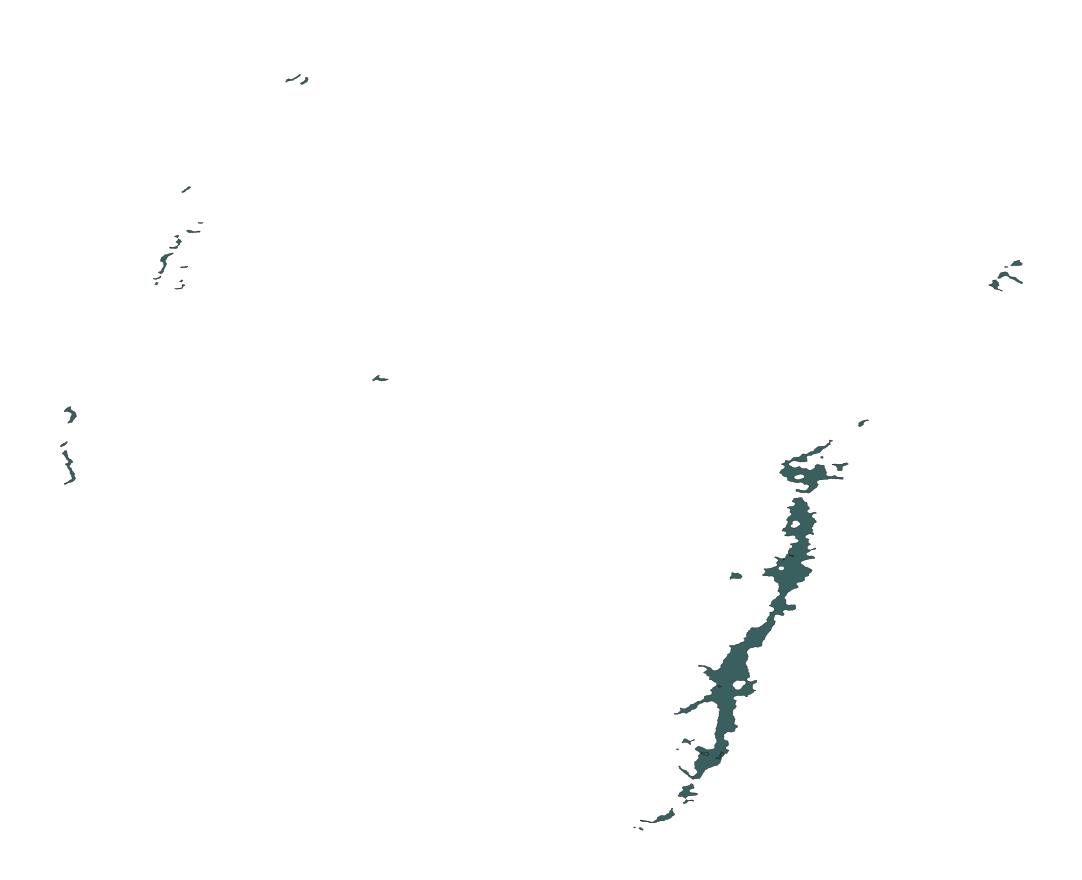

In [13]:
closed_aocs = dissolved_by_app.copy()
if BUFFER_DIST_M > 0:
    closed_aocs.geometry = closed_aocs.geometry.buffer(BUFFER_DIST_M).buffer(-BUFFER_DIST_M)
    closed_aocs = repair_frame(closed_aocs)

display(metrics_for_frame(f"morphological close {BUFFER_DIST_M} m", closed_aocs))
plot_frame(closed_aocs, f"D5. Morphological close at {BUFFER_DIST_M} m: {REGION_NAME}", linewidth=0.2)
plt.show()

{'label': 'simplified 250 m',
 'feature_count': 49,
 'app_count': 49,
 'coordinate_count': 866,
 'geometry_part_count': 120,
 'invalid_geometry_count': 0,
 'empty_geometry_count': 0,
 'approx_geojson_size_mb': 0.0413,
 'area_m2_epsg_2154': 339596873.3098539}

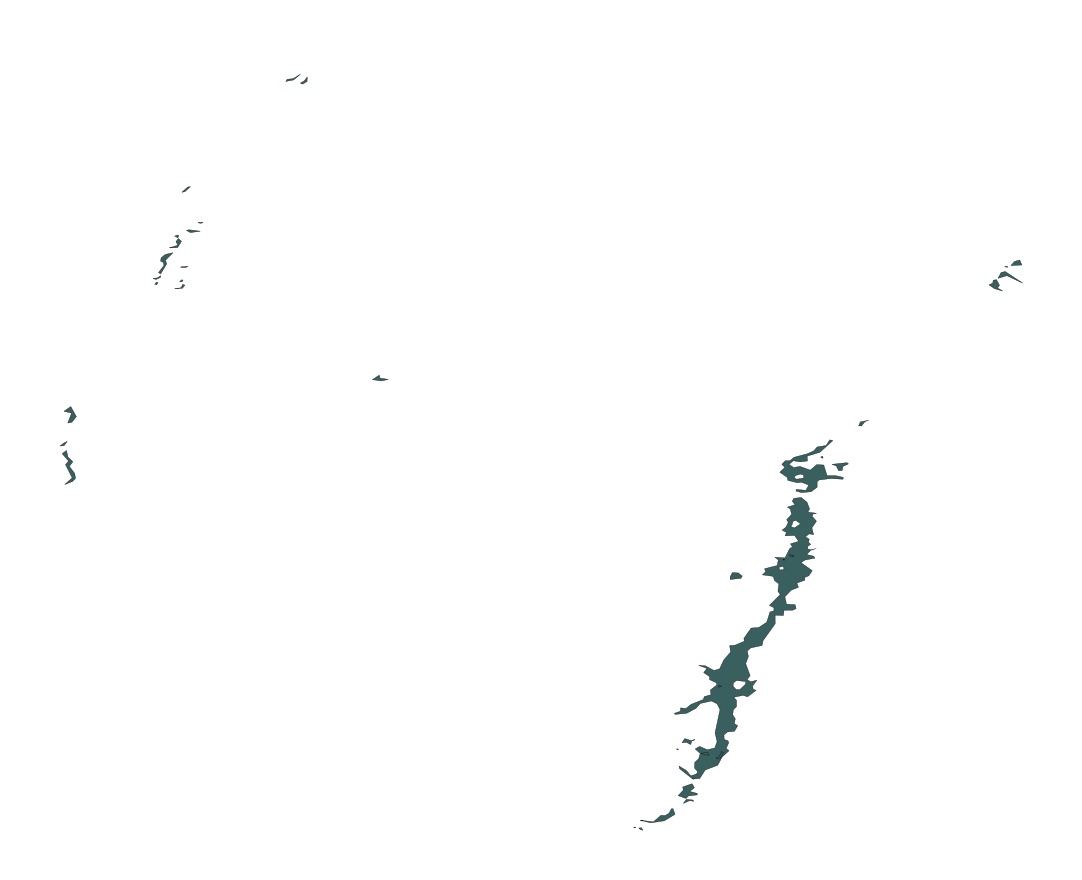

In [14]:
simplified_aocs = closed_aocs.copy()
if SIMPLIFY_M > 0:
    simplified_aocs.geometry = simplified_aocs.geometry.simplify(SIMPLIFY_M, preserve_topology=True)
    simplified_aocs = repair_frame(simplified_aocs)

display(metrics_for_frame(f"simplified {SIMPLIFY_M} m", simplified_aocs))
plot_frame(simplified_aocs, f"D6. Simplified at {SIMPLIFY_M} m: {REGION_NAME}", linewidth=0.2)
plt.show()

{'label': 'final processed candidate',
 'feature_count': 49,
 'app_count': 49,
 'coordinate_count': 866,
 'geometry_part_count': 120,
 'invalid_geometry_count': 0,
 'empty_geometry_count': 0,
 'approx_geojson_size_mb': 0.0413,
 'area_m2_epsg_2154': 339596873.30985415}

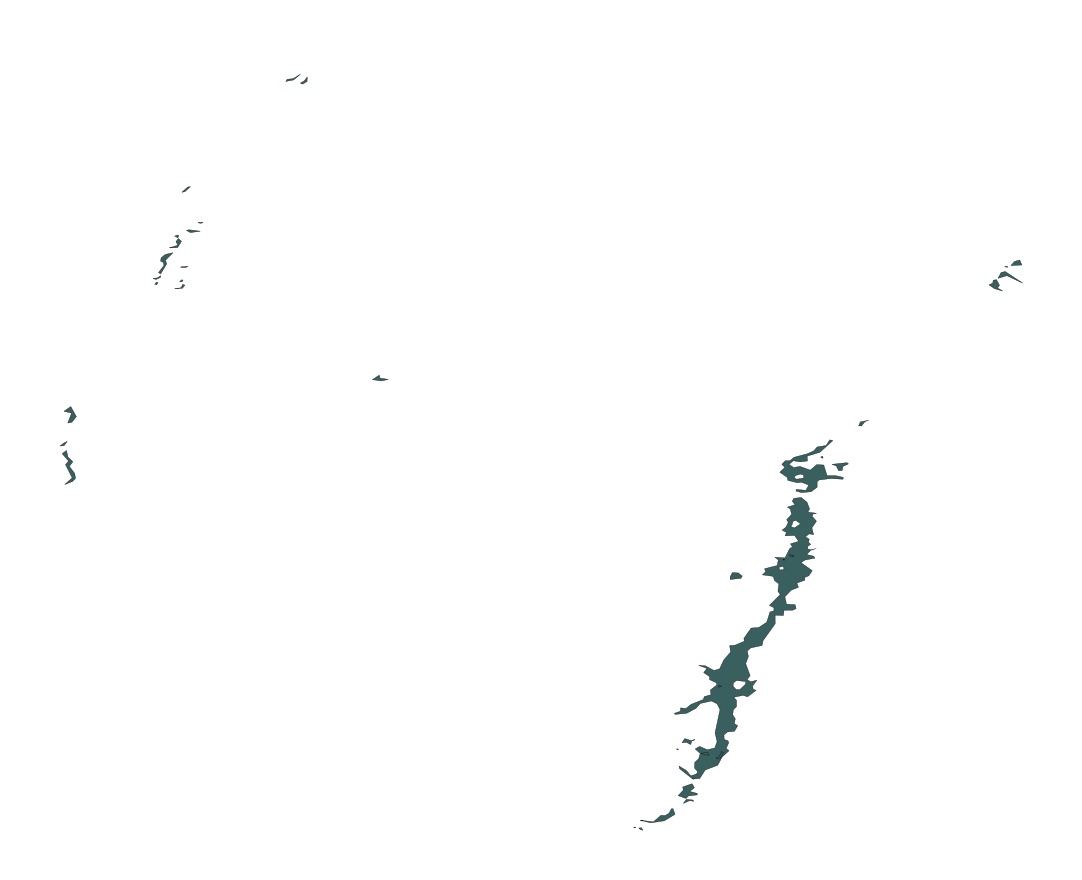

In [15]:
final_candidate = simplified_aocs.copy()

if EXTRACT_LARGEST_POLYGON or MIN_PART_AREA_M2 > 0 or MAX_PARTS_PER_APP is not None:
    part_rows = []
    for _, row in final_candidate.iterrows():
        parts = collect_polygon_parts(row.geometry)
        for part in parts:
            part_rows.append({
                "region": row["region"],
                "app": row["app"],
                "colour": row["colour"],
                "part_area_m2": float(part.area),
                "geometry": part,
            })
    part_frame = gpd.GeoDataFrame(part_rows, geometry="geometry", crs=final_candidate.crs)
    part_frame = part_frame.sort_values(["app", "part_area_m2"], ascending=[True, False])
    part_frame["part_rank"] = part_frame.groupby("app", sort=False).cumcount() + 1
    if EXTRACT_LARGEST_POLYGON:
        part_frame = part_frame.loc[part_frame["part_rank"] == 1].copy()
    if MIN_PART_AREA_M2 > 0:
        part_frame = part_frame.loc[part_frame["part_area_m2"] >= MIN_PART_AREA_M2].copy()
    if MAX_PARTS_PER_APP is not None:
        part_frame = part_frame.loc[part_frame["part_rank"] <= MAX_PARTS_PER_APP].copy()
    final_candidate = part_frame[["region", "app", "colour", "geometry"]].copy()

final_candidate = repair_frame(final_candidate)
final_candidate_wgs84 = final_candidate.to_crs(EXPORT_CRS)

display(metrics_for_frame("final processed candidate", final_candidate_wgs84))
plot_frame(final_candidate_wgs84, f"D7. Final processed AOC-first candidate: {REGION_NAME}", linewidth=0.2)
plt.show()

## E. Stage Plots

A side-by-side panel for finding exactly where fidelity changes.

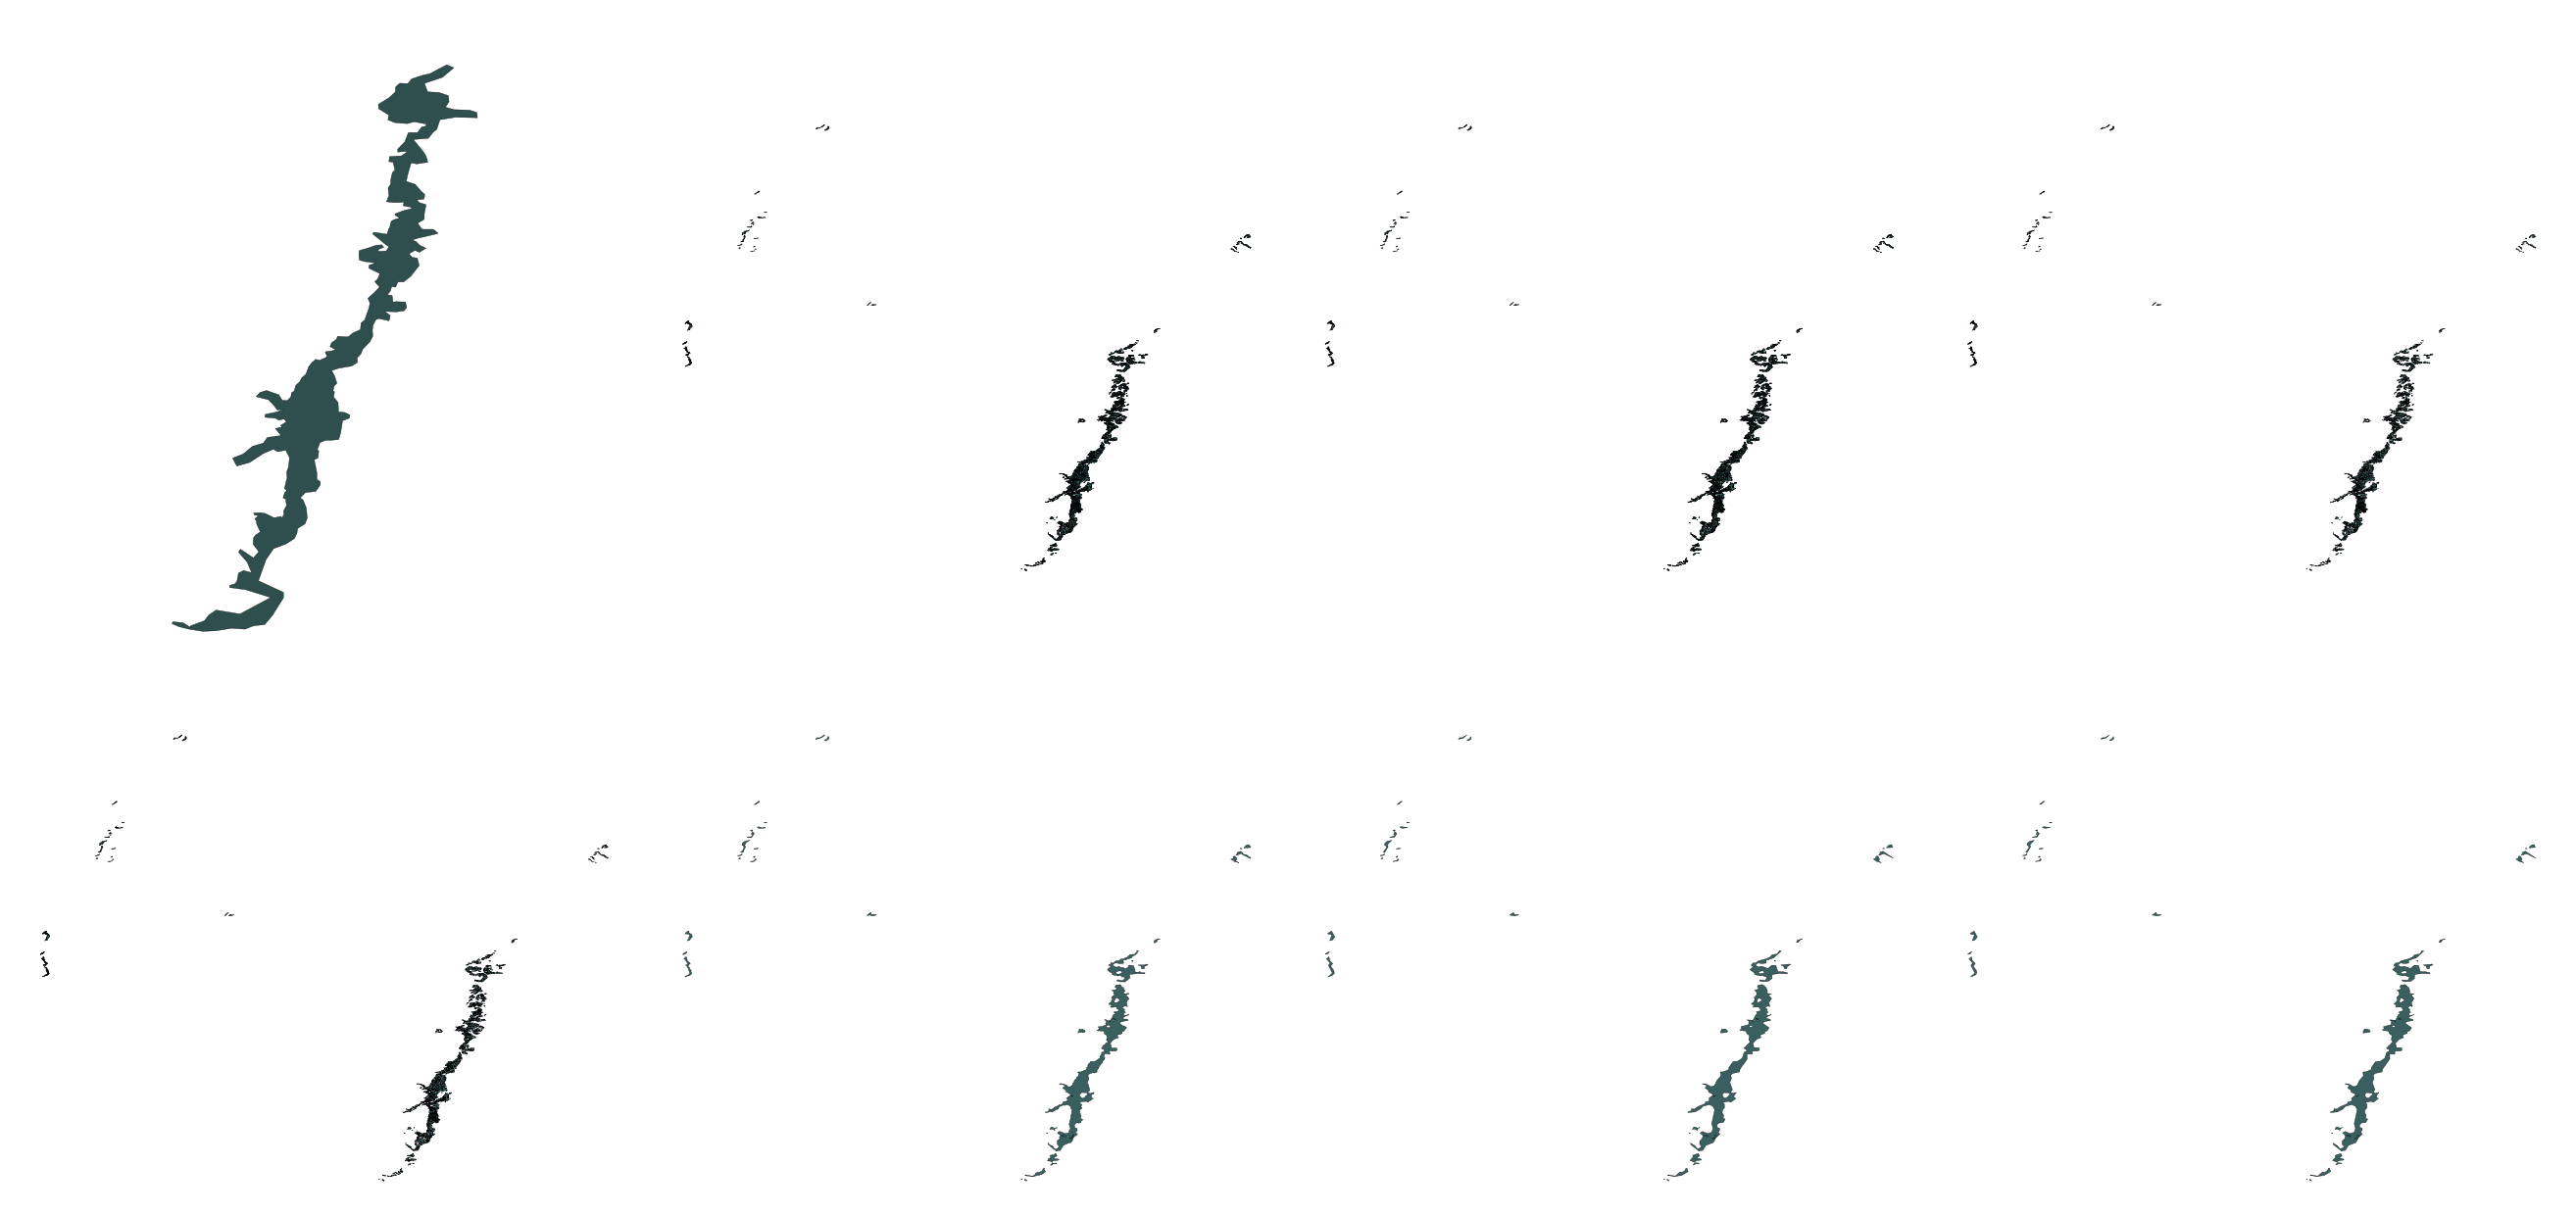

In [16]:
stage_items = [
    (old_region, "Old app geometry"),
    (new_region, "Raw source AOCs"),
    (repaired_aocs, "Repaired AOCs"),
    (overlap_clipped, "Overlap-clipped AOCs" if OVERLAP_CLIP_ENABLED else "Overlap clip disabled"),
    (dissolved_by_app, "Dissolved by app"),
    (closed_aocs, "Morphological close"),
    (simplified_aocs, "Simplified AOCs"),
    (final_candidate_wgs84, "Final candidate"),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 11), dpi=120)
fig.patch.set_facecolor("white")
for ax, (frame, title) in zip(axes.flat, stage_items):
    plot_frame(frame, title, ax=ax, linewidth=0.2)
fig.tight_layout()
plt.show()

## F. Metrics Versus Old Data

Compare old app geometry, raw new AOC source, and the processed AOC-first candidate for the selected region. The region-set table distinguishes shared, new-only, and old-only regions.

In [17]:
comparison_metrics = pd.DataFrame([
    metrics_for_frame("old app geometry", old_region, app_column="app"),
    metrics_for_frame("raw new AOCs", new_region),
    metrics_for_frame("processed AOC-first candidate", final_candidate_wgs84),
])

display(region_sets)
display(comparison_metrics)

,regions
shared_regions,"[Alsace, Bordeaux, Bourgogne, Dordogne, Langue..."
new_only_regions,"[Corse, Jura, Savoie, Sud-Ouest]"
old_only_regions,[Champagne]


,label,feature_count,app_count,coordinate_count,geometry_part_count,invalid_geometry_count,empty_geometry_count,approx_geojson_size_mb,area_m2_epsg_2154
0,old app geometry,1,NaN,331,1,0,0,0.0128,3.733086e+08
1,raw new AOCs,55,55.0,265863,2626,3,0,10.2216,4.322898e+08
2,processed AOC-first candidate,49,49.0,866,120,0,0,0.0413,3.395969e+08


## G. Missing-Region Tests

Quick visual tests for priority missing regions: Sud-Ouest, Savoie, Jura, and Corse. This compact helper mirrors the visible pipeline above; use it only after inspecting the full selected-region stages.

,label,feature_count,app_count,coordinate_count,geometry_part_count,invalid_geometry_count,empty_geometry_count,approx_geojson_size_mb,area_m2_epsg_2154
0,Sud-Ouest,17,17,4454,409,0,0,0.1811,2.971633e+09
1,Savoie,2,2,389,51,0,0,0.0155,1.250901e+08
2,Jura,3,3,541,54,0,0,0.0215,2.175841e+08
3,Corse,4,4,1172,48,0,0,0.0456,1.064699e+09


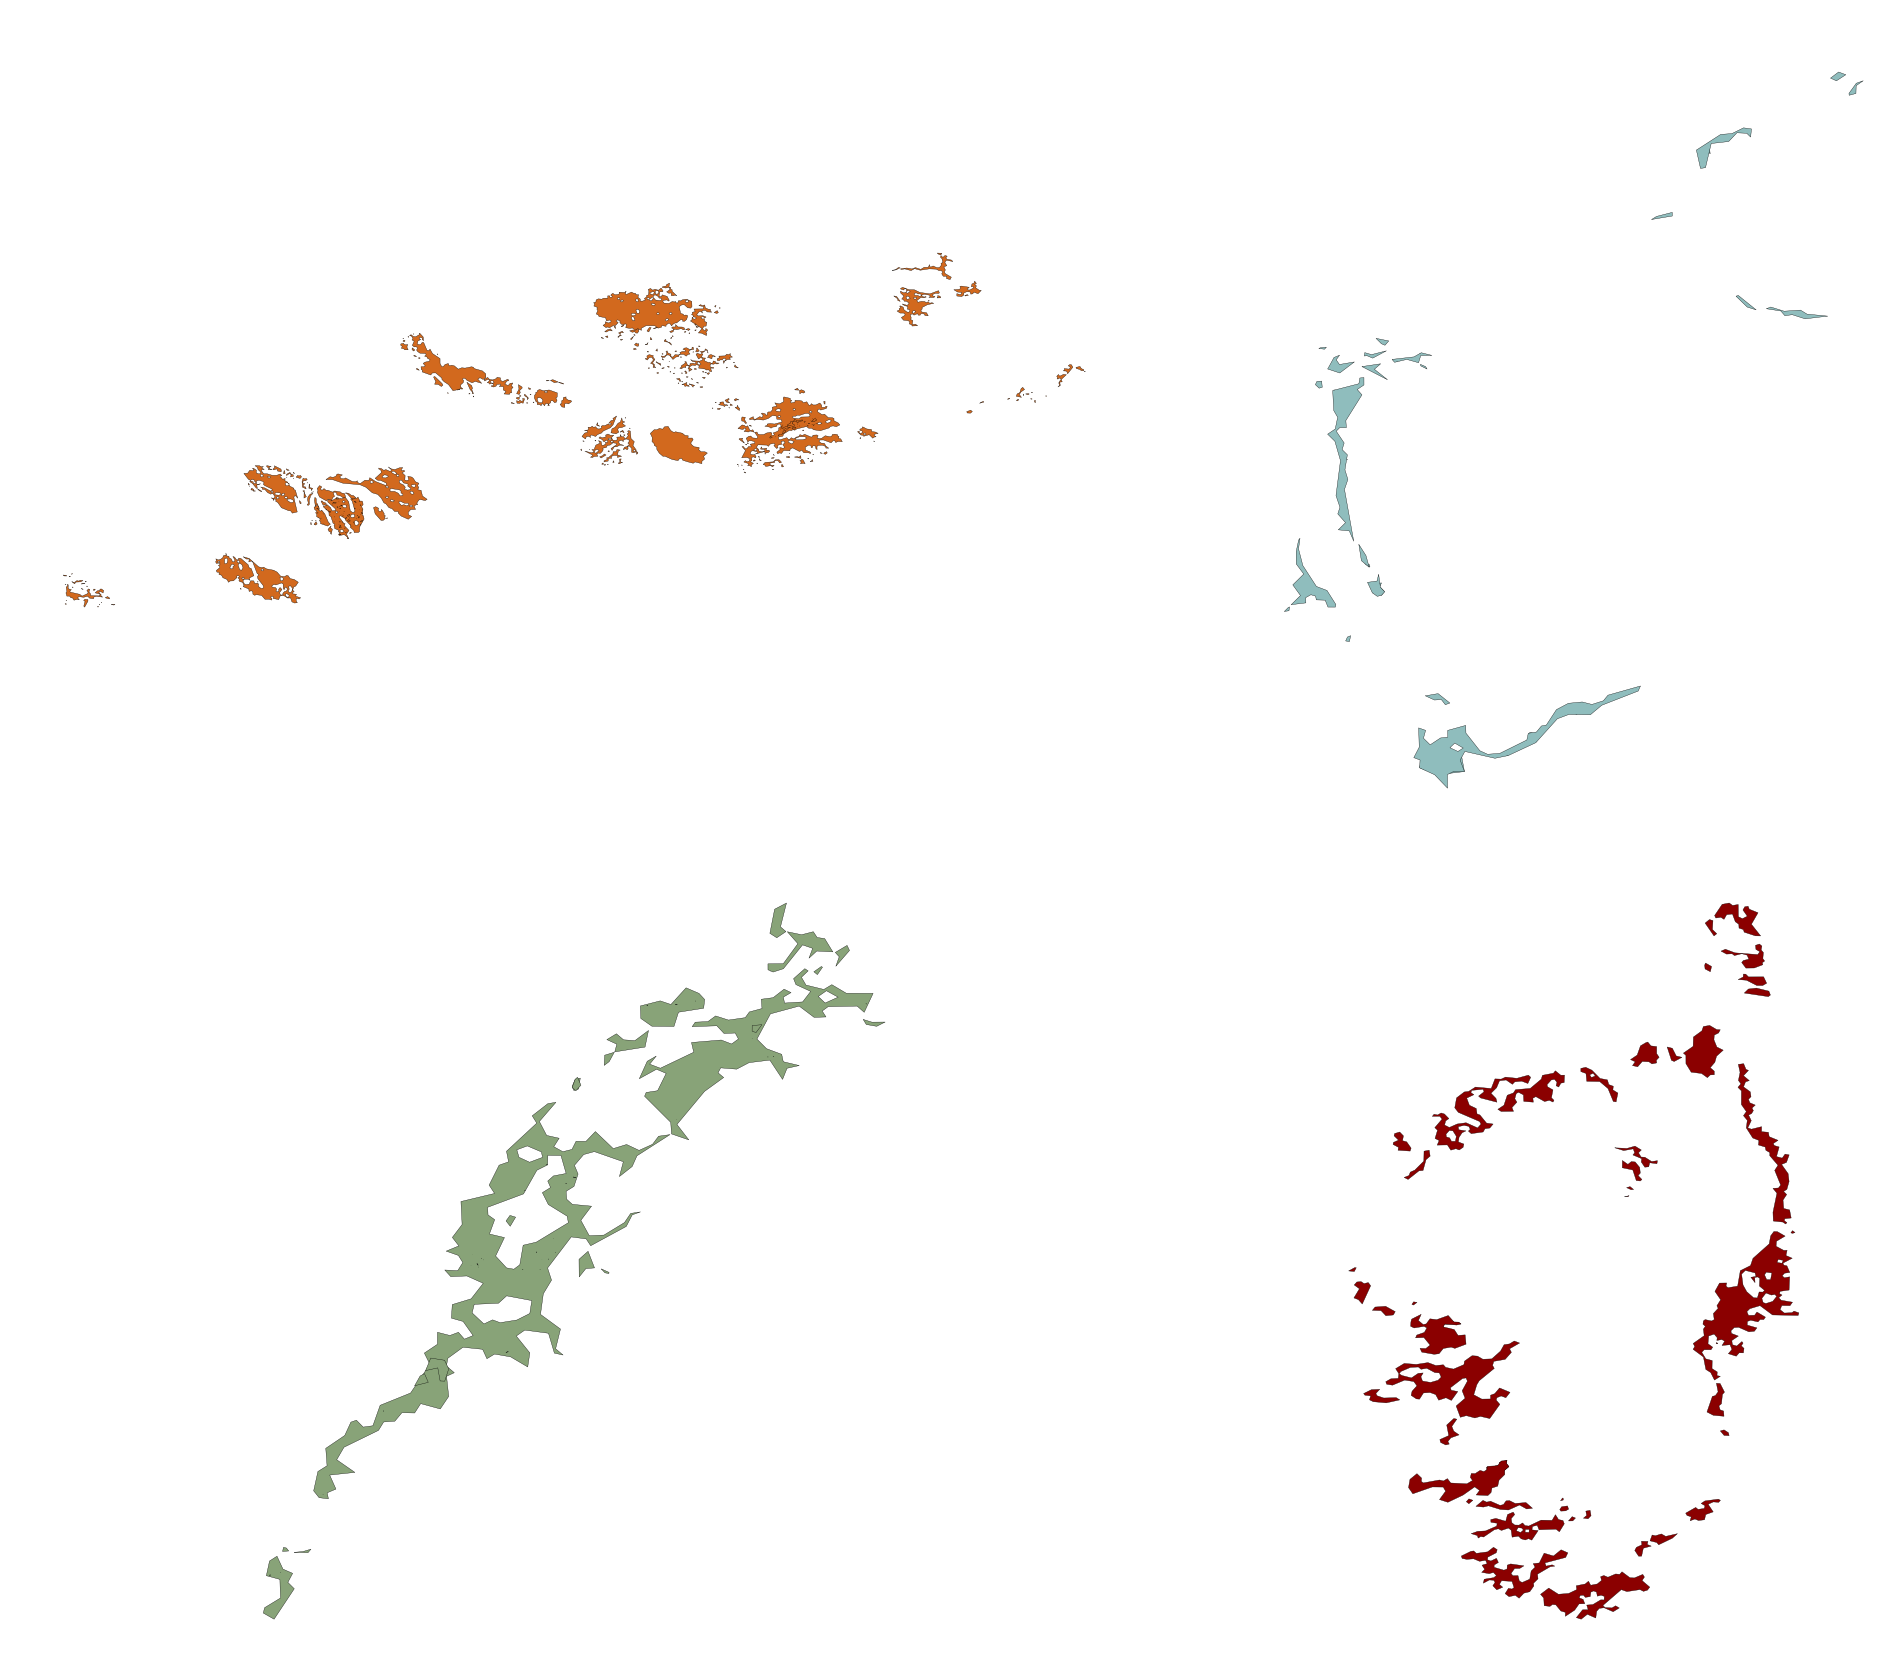

In [18]:
def quick_aoc_first_candidate(region_name):
    region_rows = aoc_source.loc[aoc_source["region"].astype(str) == region_name, REQUIRED_AOC_COLUMNS].copy()
    if region_rows.empty:
        return None
    region_rows = region_rows.reset_index(drop=True)
    metric = repair_frame(region_rows.to_crs(WORK_CRS))

    if OVERLAP_CLIP_ENABLED:
        clipped_rows = []
        kept_geometries = []
        ordered = metric.assign(_area=metric.geometry.area).sort_values("_area", ascending=False)
        for _, row in ordered.iterrows():
            geom = row.geometry
            if kept_geometries:
                geom = geom.difference(unary_union(kept_geometries))
            geom = repair_one(geom)
            if geom is None or geom.is_empty:
                continue
            new_row = row.drop(labels=["_area"]).copy()
            new_row["geometry"] = geom
            clipped_rows.append(new_row)
            kept_geometries.append(geom)
        metric = gpd.GeoDataFrame(clipped_rows, geometry="geometry", crs=metric.crs)

    candidate = metric[["region", "app", "colour", "geometry"]].dissolve(by=["region", "app", "colour"], as_index=False)
    candidate = repair_frame(candidate)
    if BUFFER_DIST_M > 0:
        candidate.geometry = candidate.geometry.buffer(BUFFER_DIST_M).buffer(-BUFFER_DIST_M)
        candidate = repair_frame(candidate)
    if SIMPLIFY_M > 0:
        candidate.geometry = candidate.geometry.simplify(SIMPLIFY_M, preserve_topology=True)
        candidate = repair_frame(candidate)
    return candidate.to_crs(EXPORT_CRS)

missing_candidates = {region: quick_aoc_first_candidate(region) for region in PRIORITY_MISSING_REGIONS}
missing_metrics = pd.DataFrame([
    metrics_for_frame(region, frame) for region, frame in missing_candidates.items() if frame is not None
])
display(missing_metrics)

fig, axes = plt.subplots(2, 2, figsize=(18, 14), dpi=120)
fig.patch.set_facecolor("white")
for ax, region in zip(axes.flat, PRIORITY_MISSING_REGIONS):
    plot_frame(missing_candidates.get(region), region, ax=ax, linewidth=0.2)
fig.tight_layout()
plt.show()

## H. Candidate Modes

Two conceptual output modes to compare before any export decision:

1. **AOC-labelled mode**: one or more features per `app`, parent `region`, preserves appellation label for future hover/click detail.
2. **Region-grouped mode**: processed AOC-derived geometries grouped/coloured by `region`, closer to the current app asset structure, but not dissolved into one generated region blob here.

,mode,label,feature_count,app_count,coordinate_count,geometry_part_count,invalid_geometry_count,empty_geometry_count,approx_geojson_size_mb,area_m2_epsg_2154
0,aoc_labelled,aoc_labelled,49,49.0,866,120,0,0,0.0413,3.395969e+08
1,region_grouped,region_grouped,49,NaN,866,120,0,0,0.0402,3.395969e+08


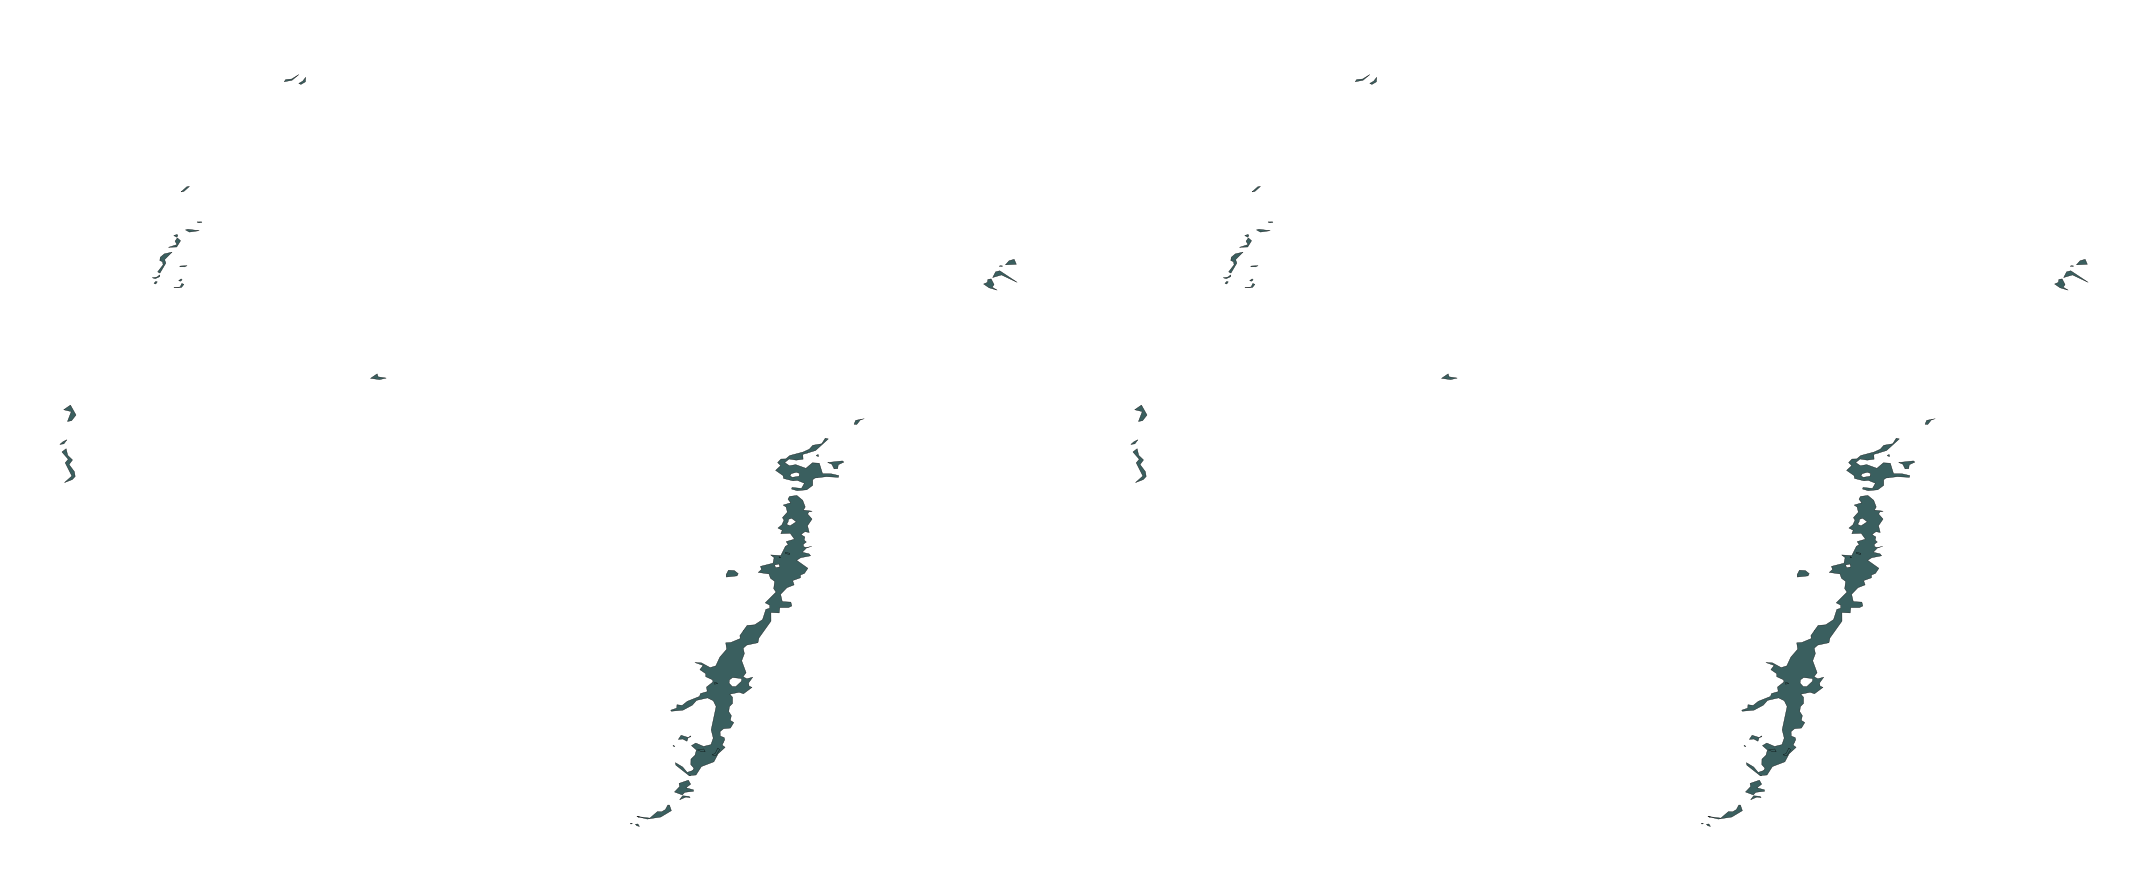

In [19]:
aoc_labelled_mode = final_candidate_wgs84[["region", "app", "colour", "geometry"]].copy()
region_grouped_mode = final_candidate_wgs84[["region", "colour", "geometry"]].copy()

display(pd.DataFrame([
    {"mode": "aoc_labelled", **metrics_for_frame("aoc_labelled", aoc_labelled_mode)},
    {"mode": "region_grouped", **metrics_for_frame("region_grouped", region_grouped_mode, app_column="app")},
]))

fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=120)
fig.patch.set_facecolor("white")
plot_frame(aoc_labelled_mode, "AOC-labelled mode", ax=axes[0], linewidth=0.2)
plot_frame(region_grouped_mode, "Region-grouped mode", ax=axes[1], linewidth=0.2)
fig.tight_layout()
plt.show()

## I. Manual Export

Disabled by default. If enabled, writes only to `Development/WineData/generated/aoc_simplification_benchmark/lab_exports/` and writes parameter metadata beside the GeoJSON. Never write to `assets/data` from this notebook.

In [ ]:
EXPORT = False
EXPORT_MODE = "aoc_labelled"  # aoc_labelled or region_grouped

export_frames = {
    "aoc_labelled": aoc_labelled_mode,
    "region_grouped": region_grouped_mode,
}

if EXPORT:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    selected_export = export_frames[EXPORT_MODE].to_crs(EXPORT_CRS)
    stem = f"aoc_simplification_{slugify(REGION_NAME)}_{EXPORT_MODE}"
    geojson_path = EXPORT_DIR / f"{stem}.geojson"
    params_path = EXPORT_DIR / f"{stem}_params.json"
    selected_export.to_file(geojson_path, driver="GeoJSON", engine="pyogrio")
    params = {
        "region_name": REGION_NAME,
        "export_mode": EXPORT_MODE,
        "buffer_dist_m": BUFFER_DIST_M,
        "simplify_m": SIMPLIFY_M,
        "overlap_clip_enabled": OVERLAP_CLIP_ENABLED,
        "extract_largest_polygon": EXTRACT_LARGEST_POLYGON,
        "min_part_area_m2": MIN_PART_AREA_M2,
        "max_parts_per_app": MAX_PARTS_PER_APP,
        "source_path": str(AOC_SOURCE_PATH),
        "old_benchmark_path": str(OLD_WINE_PATH),
    }
    params_path.write_text(json.dumps(params, indent=2, sort_keys=True) + "\n", encoding="utf-8")
    print(geojson_path)
    print(params_path)
else:
    print("Export disabled. Set EXPORT = True in this cell to write a lab candidate and sidecar JSON.")